# Phishing Website Detection using Machine Learning

## Notebook 08: Model Interpretability

### Objective

The objective of this notebook is to interpret the final LightGBM model by identifying the most influential features used for phishing website detection. Model interpretability helps explain how the trained model makes predictions and increases confidence in its decisions.

---


## 1. Import Libraries

Import the required libraries for hyperparameter tuning, model evaluation, and saving the optimized models.

In [1]:
# To load the trained LightGBM model.
import joblib

# To load and manipulate the dataset.
import pandas as pd

# Visualize feature importance.
import matplotlib.pyplot as plt

# Provides utilities for working with LightGBM models.
import lightgbm as lgb

# Explains model predictions by measuring the contribution of each feature.
import shap              

## 3. Load the Final Model

Load the final optimized LightGBM model developed during hyperparameter tuning.

In [2]:
model = joblib.load("../models/tuned/LightGBM.pkl")

## 4. Load the Dataset

Load the engineered phishing website dataset and separate the input features from the target variable.

In [3]:
df = pd.read_csv("../dataset/engineered_phishing_dataset.csv")

X = df.drop("phishing", axis=1)
y = df["phishing"]


## 5. Feature Importance

**Question:** Which website features have the greatest influence on the final LightGBM model?

Visualize the feature importance scores learned by the LightGBM model to identify the most influential features used for phishing website detection.

In [4]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
16,length_url,631
20,num_vowels_dom,408
35,length_path,345
42,length_file,287
17,num_dots_dom,121
3,num_slash_url,110
1,num_hyph_url,104
0,num_dots_url,104
24,num_hyph_path,101
26,num_slash_path,68


### Note:
If importance of length_url = 631 then,
during training, LightGBM used length_url around 630 times to split nodes in the decision trees.

### Top 10 Important Features

Display the ten most important features identified by the trained LightGBM model.

In [5]:
feature_importance.head(10)

,Feature,Importance
16,length_url,631
20,num_vowels_dom,408
35,length_path,345
42,length_file,287
17,num_dots_dom,121
3,num_slash_url,110
1,num_hyph_url,104
0,num_dots_url,104
24,num_hyph_path,101
26,num_slash_path,68


### Visualize Feature Importance

Plot the top ten most important features used by the LightGBM model.

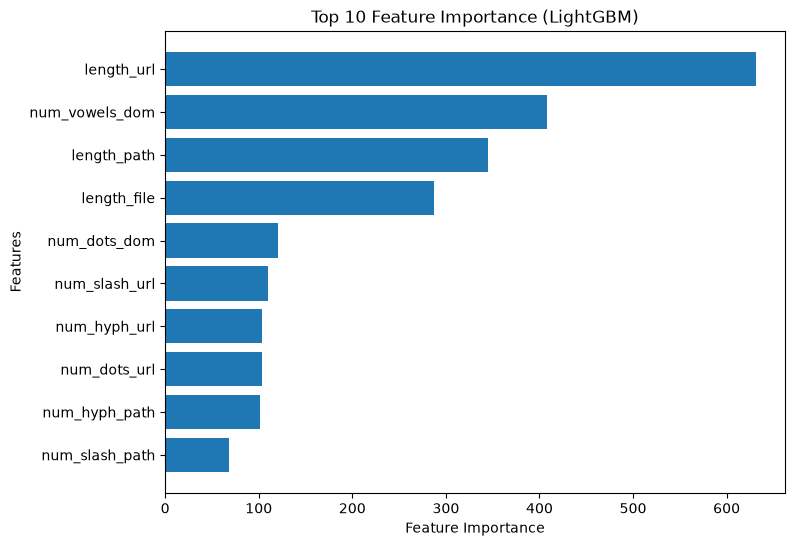

In [6]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance (LightGBM)")

plt.gca().invert_yaxis()

plt.show()

### Interpretation

- The LightGBM model assigns an importance score to every feature based on how frequently it is used to split the decision trees during training.
- The importance values are presented as percentages, making it easier to compare the relative contribution of different features.
- The results show that **length_url** is the most influential feature, indicating that the overall URL length plays a major role in distinguishing phishing websites from legitimate websites.
- Features such as **num_vowels_dom**, **length_path**, and **length_file** also contribute significantly to the model's predictions.
- Overall, the feature importance analysis highlights the website characteristics that the LightGBM model relies on most for phishing website detection.

## 6. SHAP Summary Plot

**Question:** How do the important features influence the LightGBM model's predictions?

Use SHAP (SHapley Additive exPlanations) to understand how individual features contribute to the prediction of phishing and legitimate websites.

### 6.1 Create SHAP Explainer

Create a SHAP explainer for the trained LightGBM model.

In [7]:
explainer = shap.TreeExplainer(model)

### 6.2 Calculate SHAP Values

Calculate the SHAP values for all features in the dataset.

In [8]:
shap_values = explainer.shap_values(X)

d:\Phishing_Website_Detection\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


### *Note*:
"The warning is generated by the SHAP library because of version-specific changes in how LightGBM models are handled. It is an informational warning and does not affect the computed SHAP values or the feature importance analysis."

---

### 6.3 SHAP Summary Plot

Visualize how each feature influences the model's predictions across all website samples.

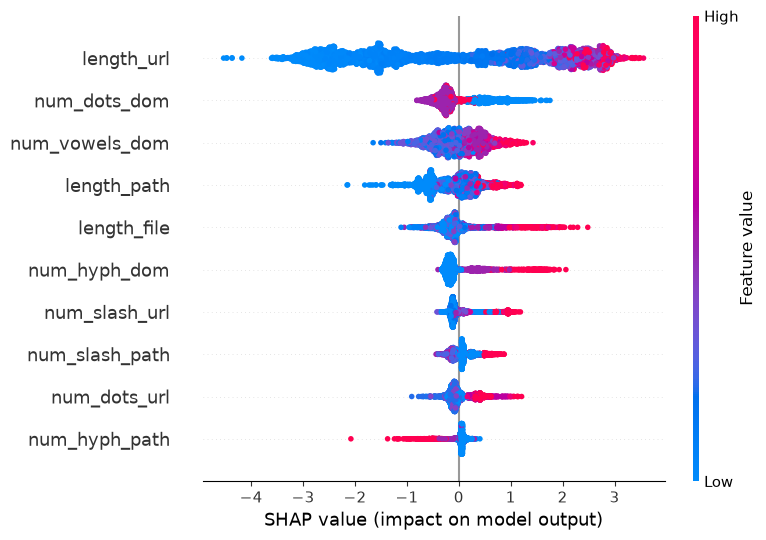

In [9]:
shap.summary_plot(
    shap_values,
    X,
    max_display=10
)

### Note: 
- In the SHAP summary plot, each dot represents one website. 
- The farther a dot is from zero, the greater the impact of that feature on the model's prediction. 
- Red dots indicate higher feature values, while blue dots indicate lower feature values. 
- Positive SHAP values increase the likelihood of predicting a phishing website, whereas negative SHAP values increase the likelihood of predicting a legitimate website.

### Interpretation

- SHAP (SHapley Additive exPlanations) provides an explanation of how each feature influences the prediction made by the LightGBM model.
- The features are ranked according to their overall impact on the model, with the most influential features appearing at the top of the plot.
- The feature **`length_url`** has the greatest influence on the model's predictions. Higher values of this feature (shown in **red**) generally push the prediction towards the **Phishing** class, while lower values (shown in **blue**) tend to push the prediction towards the **Legitimate** class.
- Other important features, including **`num_dots_dom`**, **`num_vowels_dom`**, **`length_path`**, and **`length_file`**, also contribute significantly to the model's decisions.
- Each point in the plot represents a single website. The horizontal position indicates the impact of that feature on the prediction, while the color represents whether the feature value is **high (red)** or **low (blue)**.
- Overall, the SHAP analysis confirms that the LightGBM model primarily relies on URL length and structural characteristics of the URL when distinguishing phishing websites from legitimate websites, making the model's predictions more transparent and interpretable.

> **Note:** In the SHAP summary plot, points located on the **right** (positive SHAP values) increase the likelihood of predicting a **Phishing** website, whereas points on the **left** (negative SHAP values) increase the likelihood of predicting a **Legitimate** website. Features appearing at the top of the plot have the greatest overall influence on the model.

---

# 7. Key Findings

- The LightGBM model's predictions were interpreted using both Feature Importance and SHAP (SHapley Additive exPlanations).
- Feature Importance identified the most influential features used by the model during training.
- SHAP provided both global and local explanations, showing how individual feature values influence the model's predictions.
- The analysis revealed that **URL length** and several URL structural characteristics are the primary indicators used to distinguish phishing websites from legitimate websites.
- The interpretability techniques increase confidence in the model by making its predictions transparent and easier to understand.

# 8. Conclusion

This notebook interpreted the final LightGBM model using Feature Importance and SHAP. The results showed that the model mainly relies on URL length and structural URL features when identifying phishing websites. These explainability techniques help make the model more transparent, trustworthy, and easier to understand.
